# Data Exploration + Mini-Dataset Build

Loads MIMIC-CXR from `data/archive.zip`, cleans the reports, samples a 2000-row mini set,
and extracts only the JPGs we actually need.

Same logic as `python -m src.data.loader`, but interactive so you can inspect the data.
Outputs:
- `data/processed/mini_dataset.csv`
- `data/images/*.jpg` (only the ~2000 we need)

In [1]:
import ast, io, re, zipfile
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

ROOT       = Path('..').resolve()
ARCHIVE    = ROOT / 'data' / 'archive.zip'
IMAGES_DIR = ROOT / 'data' / 'images'
MINI_CSV   = ROOT / 'data' / 'processed' / 'mini_dataset.csv'
QA_CSV     = ROOT / 'data' / 'synthetic_qa' / 'qa_dataset.csv'
IMG_PREFIX = 'official_data_iccv_final/'

TARGET_N   = 2000
OVERSAMPLE = 1.5  # zip only contains ~73% of referenced images

## 1. Load metadata

In [2]:
with zipfile.ZipFile(ARCHIVE) as zf:
    with zf.open('mimic_cxr_aug_train.csv') as f:
        df = pd.read_csv(f)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
print(f'Shape: {df.shape}')
df.head(2)

Shape: (64586, 8)


,subject_id,image,view,AP,PA,Lateral,text,text_augment
0,10000032,['files/p10/p10000032/s50414267/02aa804e-bde0a...,"['PA', 'LATERAL', 'AP']",['files/p10/p10000032/s53911762/68b5c4b1-227d0...,['files/p10/p10000032/s50414267/02aa804e-bde0a...,['files/p10/p10000032/s50414267/174413ec-4ec4c...,"['Findings: There is no focal consolidation, p...","['Findings: There is no focus, pleural effusio..."
1,10000764,['files/p10/p10000764/s57375967/096052b7-d256d...,"['AP', 'LATERAL']",['files/p10/p10000764/s57375967/096052b7-d256d...,[],['files/p10/p10000764/s57375967/b79e55c3-735ce...,['Findings: PA and lateral views of the chest ...,['Finds: PA and lateral view of the breast int...


In [3]:
def first_of_list(val):
    try:
        x = ast.literal_eval(val)
        return x[0] if isinstance(x, list) and x else ''
    except Exception:
        return ''

df['raw_text']   = df['text'].apply(first_of_list)
df['image_path'] = df['image'].apply(lambda v: IMG_PREFIX + first_of_list(v) if v else None)
df['study_id']   = df['image_path'].str.extract(r'/(s\d+)/')
df[['subject_id', 'study_id', 'image_path']].head(3)

,subject_id,study_id,image_path
0,10000032,s50414267,official_data_iccv_final/files/p10/p10000032/s...
1,10000764,s57375967,official_data_iccv_final/files/p10/p10000764/s...
2,10000898,s50771383,official_data_iccv_final/files/p10/p10000898/s...


## 2. Visualize X-rays + report length distribution

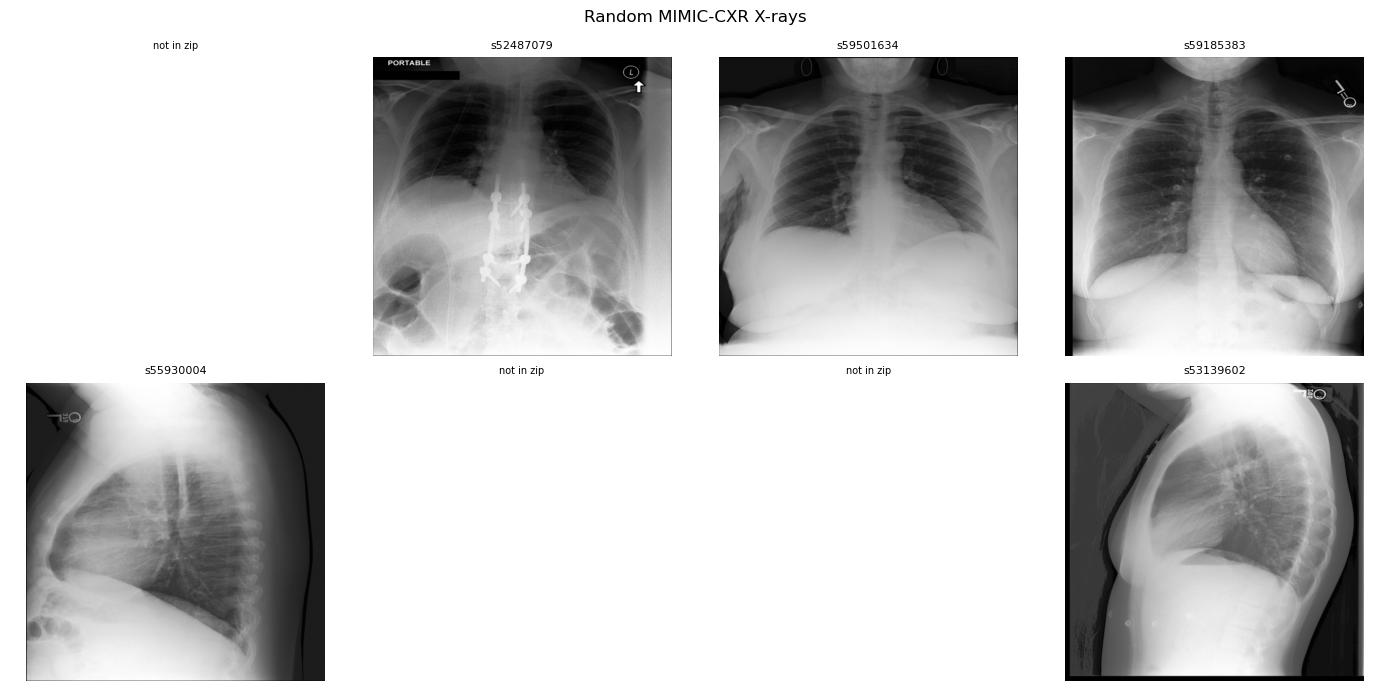

In [4]:
sample = df[df['image_path'].notna()].sample(8, random_state=7)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
with zipfile.ZipFile(ARCHIVE) as zf:
    available = set(zf.namelist())
    for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
        p = row['image_path']
        if p not in available:
            ax.set_title('not in zip', fontsize=7); ax.axis('off'); continue
        with zf.open(p) as f:
            ax.imshow(Image.open(io.BytesIO(f.read())).convert('L'), cmap='gray')
        ax.set_title(row['study_id'], fontsize=8); ax.axis('off')
plt.suptitle('Random MIMIC-CXR X-rays'); plt.tight_layout(); plt.show()

count    64586.000000
mean        52.281563
std         31.450274
min          2.000000
25%         33.000000
50%         45.000000
75%         65.000000
max        514.000000
Name: report_len, dtype: float64


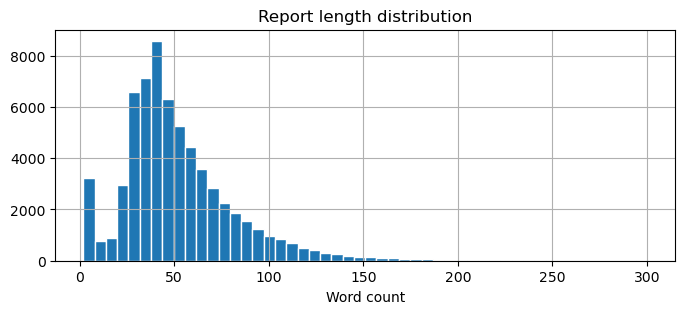

In [5]:
df['report_len'] = df['raw_text'].str.split().str.len()
print(df['report_len'].describe())
df['report_len'].clip(upper=300).hist(bins=50, edgecolor='white', figsize=(8, 3))
plt.xlabel('Word count'); plt.title('Report length distribution'); plt.show()

## 3. Clean reports

In [6]:
def clean_report(text: str) -> str:
    text = re.sub(r'(?i)\b(findings|impression)\s*:', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df['cleaned_report'] = df['raw_text'].map(clean_report)
df[['raw_text', 'cleaned_report']].head(2)

,raw_text,cleaned_report
0,"Findings: There is no focal consolidation, ple...","There is no focal consolidation, pleural effus..."
1,Findings: PA and lateral views of the chest pr...,PA and lateral views of the chest provided. Th...


## 4. Sample mini set (QA-priority if QA CSV exists)

In [7]:
candidates = df[df['image_path'].notna() & (df['raw_text'].str.len() > 80)]

qa_studies = set()
if QA_CSV.exists():
    qa_studies = set(pd.read_csv(QA_CSV)['study_id'].unique())
    print(f'Found existing QA for {len(qa_studies)} studies - prioritizing them')

if qa_studies:
    priority = candidates[candidates['study_id'].isin(qa_studies)]
    others   = candidates[~candidates['study_id'].isin(qa_studies)]
    n_others = max(int(TARGET_N * OVERSAMPLE) - len(priority), 0)
    n_others = min(n_others, len(others))
    mini = pd.concat([priority, others.sample(n=n_others, random_state=42)], ignore_index=True)
else:
    n = min(int(TARGET_N * OVERSAMPLE), len(candidates))
    mini = candidates.sample(n=n, random_state=42).reset_index(drop=True)

print(f'Candidates: {len(mini)} ({len(qa_studies)} QA-priority + filler)')

Found existing QA for 347 studies - prioritizing them
Candidates: 3000 (347 QA-priority + filler)


## 5. Extract only the JPGs we need

In [8]:
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
local_paths = []; missing = 0
with zipfile.ZipFile(ARCHIVE) as zf:
    names = set(zf.namelist())
    for p in tqdm(mini['image_path'], desc='Extracting'):
        out = IMAGES_DIR / Path(p).name
        if out.exists():
            local_paths.append(str(out))
        elif p in names:
            with zf.open(p) as src, open(out, 'wb') as dst:
                dst.write(src.read())
            local_paths.append(str(out))
        else:
            local_paths.append(None); missing += 1
print(f'{missing} images not in zip')
mini['local_path'] = local_paths
mini = mini.dropna(subset=['local_path']).head(TARGET_N).reset_index(drop=True)
print(f'Final mini set: {len(mini)} rows')

Extracting:   0%|          | 0/3000 [00:00<?, ?it/s]

839 images not in zip
Final mini set: 2000 rows


## 6. Save

In [9]:
MINI_CSV.parent.mkdir(parents=True, exist_ok=True)
mini.to_csv(MINI_CSV, index=False)
print(f'Saved {MINI_CSV}')
mini.head(3)

Saved C:\Users\Mohammed Hassan\Zewail\Y4\Spring\DSAI 413 - Multimedia\Assignments\A2\repo\data\processed\mini_dataset.csv


,subject_id,image,view,AP,PA,Lateral,text,text_augment,raw_text,image_path,study_id,report_len,cleaned_report,local_path
0,10008304,['files/p10/p10008304/s50053244/68bdf27f-1354e...,"['LATERAL', 'AP']",['files/p10/p10008304/s50053244/eee6e206-f7bc4...,[],['files/p10/p10008304/s50053244/68bdf27f-1354e...,"['Findings: No focal consolidation, pleural ef...","['Findings: There is no combustion density, pl...","Findings: No focal consolidation, pleural effu...",official_data_iccv_final/files/p10/p10008304/s...,s50053244,33,"No focal consolidation, pleural effusion, pneu...",C:\Users\Mohammed Hassan\Zewail\Y4\Spring\DSAI...
1,10033409,['files/p10/p10033409/s56976954/18ef149f-d7967...,"['LATERAL', 'AP']",['files/p10/p10033409/s56976954/cc94e085-6e5d0...,[],['files/p10/p10033409/s56976954/18ef149f-d7967...,['Findings: Low lung volumes accentuates the s...,['Results: Low lung volume accentuates the siz...,Findings: Low lung volumes accentuates the siz...,official_data_iccv_final/files/p10/p10033409/s...,s56976954,68,Low lung volumes accentuates the size of the c...,C:\Users\Mohammed Hassan\Zewail\Y4\Spring\DSAI...
2,10042350,['files/p10/p10042350/s50379033/1c17ef06-a1eaa...,['AP'],['files/p10/p10042350/s50379033/1c17ef06-a1eaa...,[],[],['Findings: The lungs are clear of interstitia...,['Findings: The lungs are free from interstiti...,Findings: The lungs are clear of interstitial ...,official_data_iccv_final/files/p10/p10042350/s...,s50379033,37,The lungs are clear of interstitial or airspac...,C:\Users\Mohammed Hassan\Zewail\Y4\Spring\DSAI...
